In [2]:
from __future__ import print_function
%matplotlib inline
import numpy
import matplotlib.pyplot as plt

# **Metode Numerik untuk Masalah Nilai Awal (Initial Value Problems)**

Sekarang kita beralih ke persamaan diferensial parsial (PDE) yang bergantung pada waktu. Kita akan terlebih dahulu mempelajari metode numerik untuk sistem persamaan diferensial biasa (ODE) yang merupakan masalah nilai awal dengan bentuk umum sebagai berikut
$$ \frac{\text{d} \vec{u}}{\text{d}t} = \vec{f}(t, \vec{u}) \quad \vec{u}(0) = \vec{u}_0 $$
Dimana
- $\vec{u}(t)$ adalah vektor keadaan (state vector)
- $\vec{f}(t, \vec{u})$ adalah fungsi bernilai vektor yang mengatur bagaimana $\vec{u}$ berubah terhadap waktu
- $\vec{u}(0)$ adalah kondisi awal pada waktu $t = 0$

dengan catatan bahwa fungsi di sisi kanan, yaitu $f$, bisa saja berasal dari proses diskretisasi ruang dari sebuah PDE, sehingga membentuk suatu sistem persamaan.

#### Contoh: Peluruhan Radioaktif Sederhana
Misalkan kita memiliki sistem dengan satu komponen
$$ \vec{u} = [c] $$
Maka sistem ODE-nya menjadi
$$\frac{\text{d} c}{\text{d}t} = -\lambda c \quad c(0) = c_0$$
dimana memiliki solusi eksak dalam bentuk $c(t) = c_0 e^{-\lambda t}$

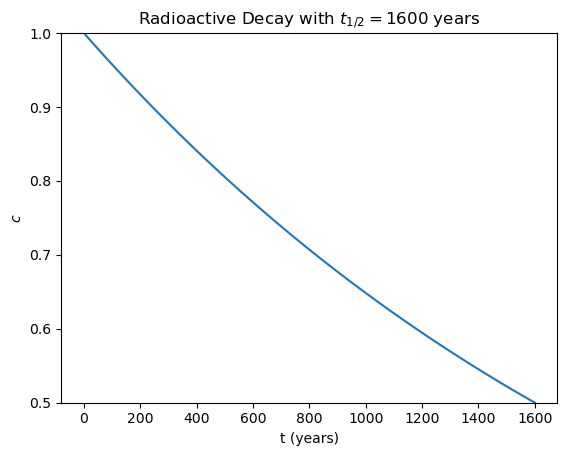

In [3]:
t = numpy.linspace(0.0, 1.6e3, 100)
c_0 = 1.0
decay_constant = numpy.log(2.0) / 1600.0

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(t, 1.0 * numpy.exp(-decay_constant * t))

axes.set_title("Radioactive Decay with $t_{1/2} = 1600$ years")
axes.set_xlabel('t (years)')
axes.set_ylabel('$c$')
axes.set_ylim((0.5,1.0))
plt.show()

#### Contoh: Peluruhan Radioaktif Kompleks (atau Sistem Kimia)
Pertimbangkan rantai peluruhan dari satu spesies ke spesies lainnya. Sistemnya dapat dimodelkan dengan persamaan diferensial berikut
$$\begin{aligned}
    \frac{\text{d} c_1}{\text{d}t} &= -\lambda_1 c_1 \\
    \frac{\text{d} c_2}{\text{d}t} &= \lambda_1 c_1 - \lambda_2 c_2 \\
    \frac{\text{d} c_2}{\text{d}t} &= \lambda_2 c_3 - \lambda_3 c_3 
\end{aligned}$$
Sistem ini bisa ditulis dalam bentuk vektor sebagai
$$\frac{\text{d} \vec{u}}{\text{d}t} = \frac{\text{d}}{\text{d}t}\begin{bmatrix} c_1 \\ c_2 \\ c_3 \end{bmatrix} = 
\begin{bmatrix} 
    -\lambda_1 & 0 & 0 \\
    \lambda_1 & -\lambda_2 & 0 \\
    0 & \lambda_2 & -\lambda_3
\end{bmatrix} \begin{bmatrix} c_1 \\ c_2 \\ c_3 \end{bmatrix}$$
atau secara ringkas 
$$\frac{\text{d} \vec{u}}{\text{d}t} = A \vec{u}$$
Untuk sistem persamaan seperti ini, solusi umum dari ODE tersebut dinyatakan dengan eksponensial matriks
$$\vec{u}(t) = \vec{u}_0 e^{A t}$$
Artinya, perubahan keadaan sistem terhadap waktu dapat dihitung dengan mengalikan kondisi awal u dengan eksponensial dari matriks 
𝐴 dikalikan waktu 𝑡. Ini sangat umum dalam sistem peluruhan berantai atau reaksi kimia bertahap

#### Contoh: Osilator Van der Pol
Persamaan diferensial orde dua Van der Pol didefinisikan sebagai
$$y'' - \mu (1 - y^2) y' + y = 0~~~~~\text{dengan syarat awal}~~~~ y(0) = y_0, ~~~y'(0) = v_0$$
Untuk menuliskannya sebagai sistem ODE orde satu, kita definisikan
$$\vec{u} = \begin{bmatrix} y \\ y' \end{bmatrix} = \begin{bmatrix} u_1 \\ u_2 \end{bmatrix}$$
Dengan demikian, sistem menjadi
$$\frac{\text{d}}{\text{d}t} \begin{bmatrix} u_1 \\ u_2 \end{bmatrix} = \begin{bmatrix} u_2 \\ \mu (1 - u_1^2) u_2 - u_1 \end{bmatrix} = \vec{f}(t, \vec{u})$$

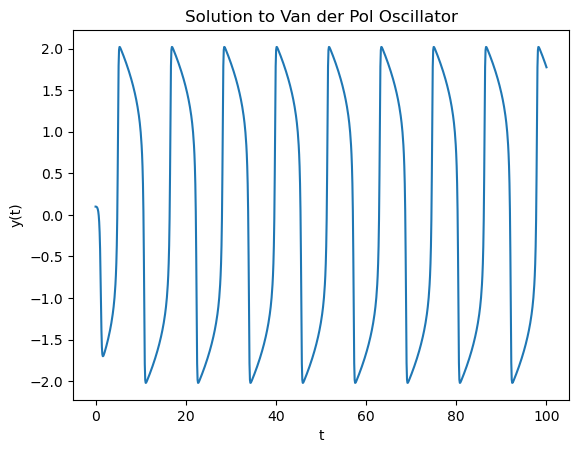

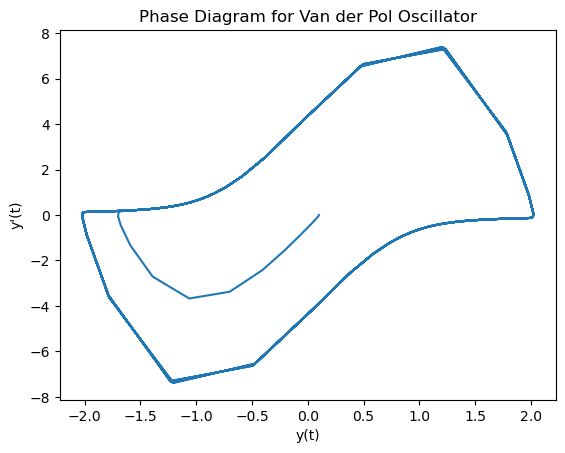

In [4]:
import scipy.integrate as integrate

def f(t, u, mu=5):
    return numpy.array([u[1], mu * (1.0 - u[0]**2) * u[1] - u[0]])

t = numpy.linspace(0.0, 100, 1000)
u = numpy.empty((2, t.shape[0]))
u[:, 0] = [0.1, 0.0]

integrator = integrate.ode(f)
integrator.set_integrator("dopri5")
integrator.set_initial_value(u[:, 0])

for (n, t_n) in enumerate(t[1:]):
    integrator.integrate(t_n)
    if not integrator.successful():
        break
    u[:, n + 1] = integrator.y
    
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

axes.plot(t, u[0,:])
axes.set_title("Solution to Van der Pol Oscillator")
axes.set_xlabel("t")
axes.set_ylabel("y(t)")

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

axes.plot(u[0,:], u[1, :])
axes.set_title("Phase Diagram for Van der Pol Oscillator")
axes.set_xlabel("y(t)")
axes.set_ylabel("y'(t)")

plt.show()

#### Contoh: Persamaan Panas (Heat Equation)
Sekarang kita akan membangun sistem ODE yang merepresentasikan persamaan panas
$$ u_t = u_{xx} $$
Jika kita melakukan diskretisasi terhadap turunan spasial $u_xx$ menggunakan finite difference orde dua dengan skema pusat (centered difference), dan menggunakan $m$ titik diskretisasi di ruang, maka kita dapatkan
$$ \frac{\text{d}}{\text{d} t} U_i(t) = \frac{U_{i+1}(t) - 2 U_i(t) + U_{i-1}(t)}{\Delta x^2} $$
Dengan cara ini, kita mengubah PDE menjadi sistem ODE sebanyak $m$ buah persamaan terhadap waktu. Pendekatan ini dikenal sebagai metode garis (method of lines) — yaitu kita mendiskretkan semua variabel kecuali waktu, sehingga menghasilkan sistem ODE yang bisa diselesaikan dengan metode numerik seperti Euler, Runge-Kutta, dll.

### **Eksistensi dan Keunikan Solusi**
Sebelum masuk ke metode numerik untuk menyelesaikan masalah nilai awal (IVP) pada ODE, langkah penting yang perlu dipahami terlebih dahulu adalah bagaimana sifat solusi dari persamaan tersebut. apakah solusinya benar-benar ada, dan jika ada, apakah solusinya unik.

### Sistem Linear
Untuk ODE linear, kita memiliki bentuk umum sistem
$$  u'(t) = A(t) u + g(t) $$
enting untuk dicatat bahwa sistem linear seperti ini selalu memiliki solusi yang unik, asalkan A(t) dan g(t) kontinu pada interval waktu yang dimaksud.

Jika 𝑔(𝑡)=0 untuk semua 𝑡, maka ODE tersebut disebut homogen. Jika selain itu matriks 𝐴 juga tidak bergantung pada waktu (konstan), maka sistem ini disebut autonom.
Dalam kasus seperti ini, solusi dari ODE memiliki bentuk eksplisit sebagai berikut
$$ u(t) = u(t_0) e^{A(t - t_0)}$$

Dalam kasus di mana $g(t) \neq 0$ untuk semua 𝑡, maka ODE tersebut disebut sebagai inhomogen. Untuk menyelesaikan sistem seperti ini, kita dapat menggunakan Prinsip Duhamel, yang memberikan bentuk solusi sebagai berikut
$$ u(t) = u(t_0) e^{A(t-t_0)} + \int^t_{t_0} e^{A(t - \tau)} g(\tau) d\tau $$
operator $e^{A(t-\tau)}$ dapat dianggap sebagai operator solusi dari ODE homogen, yang memetakan keadaan pada waktu 𝜏 ke keadaan pada waktu 𝑡

### Keberadaan dan Keunikan untuk Sistem Non-Linear

#### Kekontinuan Lipschitz
Untuk memperluas konsep keunikan solusi pada ODE non-linear, dibutuhkan jenis kekontinuan khusus yang disebut kekontinuan Lipschitz (Lipschitz continuity). Pertimbangkan ODE itu
$$ u'(t) = f(u,t),  \quad \quad \quad u(t_0) = u_0 $$
Agar solusi dari persamaan ini eksis dan unik, kita tidak cukup hanya membutuhkan fungsi f(u,t) kontinu, kita juga membutuhkan fungsi tersebut memiliki tingkat "kekasaran" atau "kelicinan" tertentu, yang dalam hal ini adalah kontinuitas Lipschitz terhadap u.

Kita mengatakan bahwa 𝑓 bersifat Lipschitz kontinu terhadap 𝑢 pada suatu domain
$$ \Omega = \{(u,t) : |u - u_0| \leq a, t_0 \leq t \leq t_1 \} $$
jika terdapat suatu konstanta 𝐿>0 sedemikian sehingga
$$ |f(u,t) - f(u^\ast, t)| \leq L |u - u^\ast| \quad \quad \forall (u,t) ~\text{and}~ (u^\ast,t) \in \Omega$$

Jika $f(u,t)$  terdiferensialkan terhadap 𝑢 yaitu turunan parsialnya $\Omega$, yaitu turunan parsialnya $f_u = \partial f / \partial u$ ada, dan terbatas (bounded), maka kita dapat menyatakan bahwa
$$ L = \max_{(u,t) \in \Omega} |f_u(u,t)|$$
hal ini berlaku karena kita bisa menulis
$$  f(u,t) = f(u^\ast, t) + f_u(v,t)(u-u^\ast)$$
untuk suatu nilai 𝑣 yang berada di antara 𝑢 dan 𝑢∗. Ekspresi ini merupakan bentuk dari rumus Taylor (tanpa sisa tingkat tinggi), yang menyatakan bahwa fungsi 𝑓 cukup halus (smooth) sehingga perubahan nilainya terhadap u dapat dikontrol melalui turunannya.

Dengan adanya kekontinuan Lipschitz pada 𝑓, kita dapat menjamin bahwa solusi dari masalah nilai awal (IVP) adalah unik dan eksis setidaknya hingga waktu $T = \min(t_1, t_0 + a/S)$ dimana 
$$ S = \max_{(u,t)\in\Omega} |f(u,t)|$$
Nilai 𝑆 ini merupakan modulus dari kemiringan maksimum (laju perubahan maksimum) yang mungkin dimiliki oleh solusi $u(t)$ dalam domain Ω.

#### Contoh 1

Misalkan diberikan ODE $u'(t) = (u(t))^2, u(0) = u_0 > 0$. Kita ingin memeriksa keberadaan dan keunikan solusi menggunakan kontinuitas Lipschitz. Kita definisikan domain Ω sebagai
$$ L = \max_{(u,t) \in \Omega} | 2 u | = 2 (u_0 + a) $$
di mana kita menggunakan batasan dari domain $\Omega$ yaitu $|u - u_0| \leq a$.  

Demikian pula, kita dapat menghitung 𝑆 dan memperoleh
$$ S = \max_{(u,t)\in\Omega} |f(u,t)| = (u_0 + a)^2 $$
sehingga kita dapat menjamin solusi yang unik hingga waktu $T  = a / (u_0 + a)^2$. Karena kita bebas memilih nilai 𝑎, maka kita bisa memilih nilai yang memaksimalkan $T$, dalam kasus ini $a = u_0$ memberikan hasil maksimum tersebut, dan kita menyimpulkan bahwa kita memiliki solusi yang unik hingga $T = 1 / 4 u_0$.

Karena kita juga mengetahui solusi eksak dari ODE di atas
$$ u(t) = \frac{1}{1/u_0 - t}$$
kita dapat melihat bahwa $|u(t)| < \infty$ selama $t \neq 1/u_0$. Perlu dicatat bahwa setelah kita mencapai titik singularitas (pole) di penyebut, tidak ada lagi solusi yang mungkin untuk IVP tersebut setelah titik tersebut. 



#### Contoh 2
Pertimbangkan IVP berikut
$$ u' = \sqrt{u} \quad \quad u(0) = 0$$
Kita ingin mengetahui: di mana fungsi 𝑓(𝑢)=𝑢 bersifat Lipschitz kontinu?

Dengan menghitung turunannya, kita peroleh
$$ f_u = \frac{1}{2\sqrt{u}}$$
yang nilainya menuju tak hingga saat 𝑢→0. Oleh karena itu, kita tidak dapat menjamin adanya solusi yang unik di sekitar kondisi awal yang diberikan.
Faktanya, kita memang mengetahui bahwa ODE ini memiliki dua solusi yang berbeda, yaitu
$$ u(t) = 0 \quad \text{and} \quad u(t) = \frac{1}{4} t^2$$

### Sistem Persamaan
Konsep yang serupa untuk kontinuitas Lipschitz juga berlaku dalam norma tertentu $||\cdot||$ , jika ada suatu konstanta 𝐿 sedemikian sehingga:
$$ ||f(u,t) - f(u^\ast,t)|| \leq L ||u - u^\ast|| $$
untuk semua pasangan $(u,t)$ dan $(u^\ast,t)$ dalam domain $\Omega = \{(u,t) : ||u-u_0|| \leq a, t_0 \leq t \leq t_1 \}$.
Perhatikan bahwa jika fungsi 𝑓 bersifat Lipschitz kontinu dalam satu norma, maka 𝑓 juga akan kontinu dalam norma apapun. Ini berarti sifat Lipschitz akan tetap terjaga meskipun kita mengganti norma yang digunakan.

### **Skema Langkah Dasar**

Kembali ke pekerjaan kita tentang diferensiasi numerik, mengapa tidak mengaproksimasi turunan menggunakan beda hingga (finite difference)
$$ \frac{u(t + \Delta t) - u(t)}{\Delta t} = f(t, u)$$
Namun, kita masih perlu memutuskan bagaimana cara mengevaluasi term 𝑓(𝑡,𝑢) tersebut

Mari kita lihat ini dari perspektif kuadratur (integrasi numerik). Ambil integral dari kedua sisi persamaan

$$\begin{aligned}
    \int^{t + \Delta t}_t \frac{\text{d} u}{\text{d}\tilde{t}} d\tilde{t} &= \int^{t + \Delta t}_t f(t, u) d\tilde{t} \\ ~ \\
u(t + \Delta t) - u(t) &= \Delta t ~f(t, u(t)) \\ ~ \\
\frac{u(t + \Delta t) - u(t)}{\Delta t} &= f(t, u(t))
\end{aligned}$$

Di sini, kita telah menggunakan aturan kuadratur kiri (left-sided quadrature rule) untuk integral pada sisi kanan. 

Dengan memperkenalkan beberapa notasi untuk menyederhanakan penulisan
$$ t_0 = 0  \quad \quad t_1 = t_0 + \Delta t  \quad \quad t_n = t_{n-1} + \Delta t = n \Delta t + t_0$$
$$ U^0 = u(t_0) \quad \quad U^1 = u(t_1) \quad \quad U^n = u(t_n)$$
Kita dapat menulis ulang skema kita sebagai
$$ \frac{U^{n+1} - U^n}{\Delta t} = f(t_n, U^n)$$
atau
$$ U^{n+1} = U^n + \Delta t f(t_n, U^n)$$
Yang dikenal sebagai metode Euler maju (forward Euler method). Secara esensial, kita mengaproksimasi turunan dengan nilai fungsi pada titik $t_n$ yang kita sedang hitung




<>:16: SyntaxWarning: invalid escape sequence '\D'
<>:16: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Ideapad\AppData\Local\Temp\ipykernel_17116\1245662689.py:16: SyntaxWarning: invalid escape sequence '\D'
  axes.text(400, u_np - 0.05, '$\Delta t$', fontsize=16)


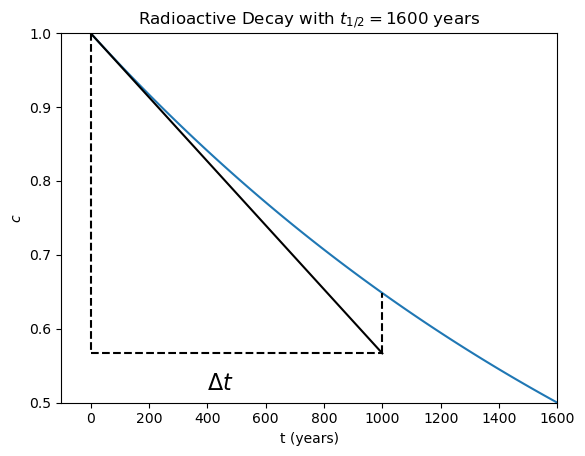

In [5]:
t = numpy.linspace(0.0, 1.6e3, 100)
c_0 = 1.0
decay_constant = numpy.log(2.0) / 1600.0

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(t, c_0 * numpy.exp(-decay_constant * t), label="True Solution")

# Plot Euler step
dt = 1e3
u_np = c_0 + dt * (-decay_constant * c_0)
axes.plot((0.0, dt), (c_0, u_np), 'k')
axes.plot((dt, dt), (u_np, c_0 * numpy.exp(-decay_constant * dt)), 'k--')
axes.plot((0.0, 0.0), (c_0, u_np), 'k--')
axes.plot((0.0, dt), (u_np, u_np), 'k--')
axes.text(400, u_np - 0.05, '$\Delta t$', fontsize=16)

axes.set_title("Radioactive Decay with $t_{1/2} = 1600$ years")
axes.set_xlabel('t (years)')
axes.set_ylabel('$c$')
axes.set_xlim(-1e2, 1.6e3)
axes.set_ylim((0.5,1.0))
plt.show()

Gambar tersebut menunjukkan perbandingan antara solusi eksak peluruhan radioaktif (garis biru melengkung) dan pendekatan numerik menggunakan metode Euler maju (garis hitam lurus). Kurva biru menggambarkan peluruhan eksponensial yang tepat dari suatu zat radioaktif dengan waktu paruh 1600 tahun. Sementara itu, garis lurus hitam mewakili satu langkah pendekatan Euler dari titik awal $t = 0$ hingga $t = 1000$, menggunakan informasi laju perubahan hanya di titik awal tersebut. Garis-garis putus-putus hitam menunjukkan ilustrasi panjang langkah waktu ($\Delta t$) dan perbedaan nilai antara pendekatan Euler dan solusi eksak.

Perhatikan di mana kita mengharapkan adanya kesalahan karena pendekatan yang kita lakukan, dan bagaimana hal ini muncul dalam contoh di bawah ini.

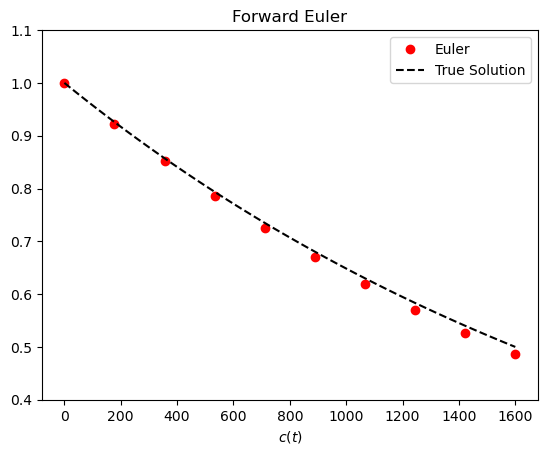

In [6]:
c_0 = 1.0
decay_constant = numpy.log(2.0) / 1600.0
f = lambda t, u: -decay_constant * u

t_exact = numpy.linspace(0.0, 1.6e3, 100)
u_exact = c_0 * numpy.exp(-decay_constant * t_exact)

# Implement Euler
t = numpy.linspace(0.0, 1.6e3, 10)
delta_t = t[1] - t[0]
U = numpy.empty(t.shape)
U[0] = c_0
for (n, t_n) in enumerate(t[:-1]):
    U[n + 1] = U[n] + delta_t * f(t_n, U[n])

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(t, U, 'or', label="Euler")
axes.plot(t_exact, u_exact, 'k--', label="True Solution")

axes.set_title("Forward Euler")
axes.set_xlabel("t (years)")
axes.set_xlabel("$c(t)$")
axes.set_ylim((0.4,1.1))
axes.legend()
plt.show()

Gambar ini menunjukkan perbandingan antara hasil pendekatan numerik menggunakan **metode Euler maju** (Forward Euler) dan **solusi eksak** dari peluruhan radioaktif. Titik-titik **merah** pada grafik mewakili hasil dari metode Euler pada setiap langkah waktu, sedangkan garis **putus-putus hitam** menunjukkan kurva solusi eksak dari persamaan diferensial yang menggambarkan peluruhan eksponensial zat radioaktif. Terlihat bahwa hasil Euler mengikuti pola kurva eksak dengan cukup baik, meskipun sedikit menyimpang karena metode ini hanya menggunakan informasi dari titik sebelumnya untuk memperkirakan titik berikutnya. 

Metode serupa dapat diturunkan jika kita menggunakan pendekatan beda hingga pusat (central difference) yang memiliki akurasi orde dua
$$\frac{U^{n+1} - U^{n-1}}{2\Delta t} = f(t_{n}, U^{n})$$
Metode ini dikenal sebagai metode leap-frog. Oleh karena itu, metode ini termasuk dalam kategori metode multi-langkah (multi-step method), meskipun secara teknis tidak menggunakan evaluasi fungsi di langkah saat ini secara langsung untuk memperbarui solusi.

<>:16: SyntaxWarning: invalid escape sequence '\D'
<>:16: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Ideapad\AppData\Local\Temp\ipykernel_17116\2769489041.py:16: SyntaxWarning: invalid escape sequence '\D'
  axes.text(400, u_np - 0.05, '$\Delta t$', fontsize=16)


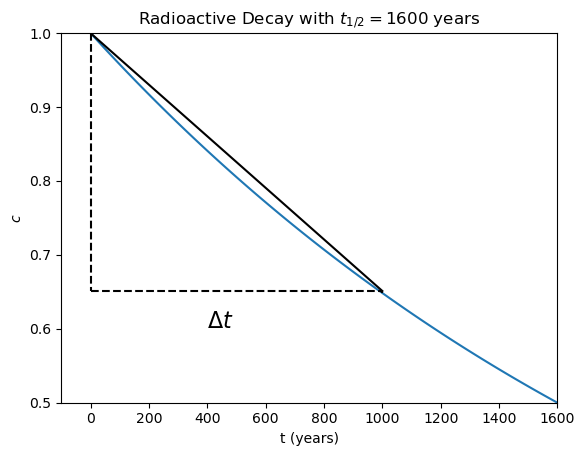

In [7]:
t = numpy.linspace(0.0, 1.6e3, 100)
c_0 = 1.0
decay_constant = numpy.log(2.0) / 1600.0

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(t, c_0 * numpy.exp(-decay_constant * t), label="True Solution")

# Plot Leap-Frog step
dt = 1e3
u_np = c_0 + dt * (-decay_constant * c_0 * numpy.exp(-decay_constant * dt / 2.0))
axes.plot((0.0, dt), (c_0, u_np), 'k')
axes.plot((dt, dt), (u_np, c_0 * numpy.exp(-decay_constant * dt)), 'k--')
axes.plot((0.0, 0.0), (c_0, u_np), 'k--')
axes.plot((0.0, dt), (u_np, u_np), 'k--')
axes.text(400, u_np - 0.05, '$\Delta t$', fontsize=16)

axes.set_title("Radioactive Decay with $t_{1/2} = 1600$ years")
axes.set_xlabel('t (years)')
axes.set_ylabel('$c$')
axes.set_xlim(-1e2, 1.6e3)
axes.set_ylim((0.5,1.0))
plt.show()

Gambar tersebut menunjukkan proses peluruhan radioaktif dengan waktu paruh 1600 tahun, di mana kurva biru menggambarkan solusi eksak berupa fungsi eksponensial dari konsentrasi zat terhadap waktu. Di atas kurva tersebut ditampilkan pendekatan numerik menggunakan metode Euler titik tengah (midpoint Euler method), yang divisualisasikan dengan garis hitam lurus dari titik awal $(0,1)$ menuju titik hasil pendekatan pada $t = 1000$ tahun. Garis-garis putus-putus hitam menunjukkan ilustrasi selisih antara solusi numerik dan solusi eksak, serta menandai interval waktu $\Delta t$. Plot ini bertujuan menunjukkan perbedaan antara hasil pendekatan numerik dengan solusi eksak, serta menggambarkan bagaimana metode Euler titik tengah bekerja untuk memperkirakan nilai konsentrasi zat radioaktif dalam selang waktu tertentu.

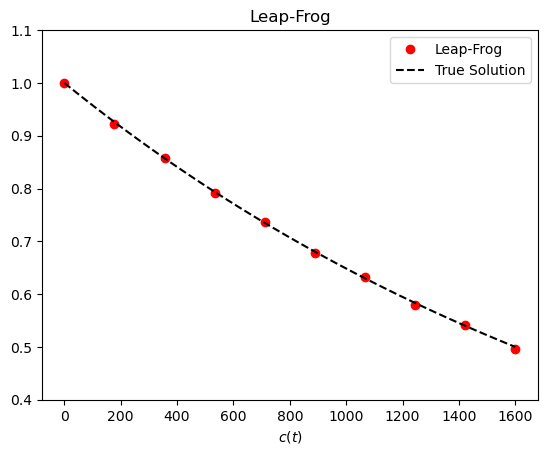

In [8]:
c_0 = 1.0
decay_constant = numpy.log(2.0) / 1600.0
f = lambda t, u: -decay_constant * u

t_exact = numpy.linspace(0.0, 1.6e3, 100)
u_exact = c_0 * numpy.exp(-decay_constant * t_exact)

# Implement leap-frog
t = numpy.linspace(0.0, 1.6e3, 10)
delta_t = t[1] - t[0]
U = numpy.empty(t.shape)
U[0] = c_0
# First evaluation use Euler to get us going
U[1] = U[0] + delta_t * f(t[0], U[0])
for n in range(1, t.shape[0] - 1):
    U[n + 1] = U[n - 1] + 2.0 * delta_t * f(t[n], U[n])

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(t, U, 'or', label="Leap-Frog")
axes.plot(t_exact, u_exact, 'k--', label="True Solution")

axes.set_title("Leap-Frog")
axes.set_xlabel("t (years)")
axes.set_xlabel("$c(t)$")
axes.set_ylim((0.4,1.1))
axes.legend()
plt.show()

Gambar tersebut menunjukkan hasil simulasi peluruhan radioaktif dengan waktu paruh 1600 tahun menggunakan metode numerik Leap-Frog yang ditandai dengan titik-titik merah, serta dibandingkan dengan solusi eksak berupa garis putus-putus hitam. Grafik memperlihatkan bahwa hasil pendekatan Leap-Frog mengikuti bentuk kurva eksponensial dengan sangat baik, meskipun hanya menggunakan 10 titik waktu. Kedekatan antara titik-titik hasil numerik dan kurva eksak menunjukkan bahwa metode Leap-Frog cukup akurat dan stabil untuk menyelesaikan model peluruhan sederhana, bahkan dengan interval waktu yang relatif besar. Hal ini membuktikan bahwa Leap-Frog merupakan metode yang efektif dalam memperkirakan perilaku sistem yang mengalami perubahan secara bertahap seperti peluruhan radioaktif.

Mirip dengan Euler maju (forward Euler), terdapat metode Euler mundur (backward Euler) yang mengevaluasi fungsi 𝑓 pada waktu yang diperbarui, yaitu pada $𝑡_𝑛+1$, menggunakan aturan kuadratur sisi kanan. Skemanya dituliskan sebagai
$$ U^{n+1} = U^n + \Delta t f(t_{n+1}, U^{n+1}) $$
Berbeda dengan Euler maju yang eksplisit, metode ini disebut sebagai metode implisit karena nilai $𝑈^𝑛+1$ muncul di kedua sisi persamaan. 

<>:16: SyntaxWarning: invalid escape sequence '\D'
<>:16: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Ideapad\AppData\Local\Temp\ipykernel_17116\1685392531.py:16: SyntaxWarning: invalid escape sequence '\D'
  axes.text(400, u_np - 0.05, '$\Delta t$', fontsize=16)


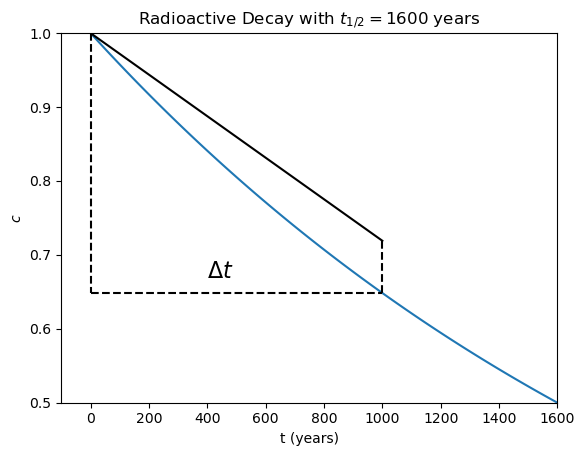

In [9]:
t = numpy.linspace(0.0, 1.6e3, 100)
c_0 = 1.0
decay_constant = numpy.log(2.0) / 1600.0

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(t, c_0 * numpy.exp(-decay_constant * t), label="True Solution")

# Plot Euler step
dt = 1e3
u_np = c_0 + dt * (-decay_constant * c_0 * numpy.exp(-decay_constant * dt))
axes.plot((0.0, dt), (c_0, u_np), 'k')
axes.plot((dt, dt), (u_np, c_0 * numpy.exp(-decay_constant * dt)), 'k--')
axes.plot((0.0, 0.0), (c_0, c_0 * numpy.exp(-decay_constant * dt)), 'k--')
axes.plot((0.0, dt), (c_0 * numpy.exp(-decay_constant * dt), c_0 * numpy.exp(-decay_constant * dt)), 'k--')
axes.text(400, u_np - 0.05, '$\Delta t$', fontsize=16)

axes.set_title("Radioactive Decay with $t_{1/2} = 1600$ years")
axes.set_xlabel('t (years)')
axes.set_ylabel('$c$')
axes.set_xlim(-1e2, 1.6e3)
axes.set_ylim((0.5,1.0))
plt.show()

Gambar di atas menunjukkan proses peluruhan radioaktif dengan waktu paruh 1600 tahun, di mana kurva biru menggambarkan solusi eksak berdasarkan rumus eksponensial $c(t) = c_0 e^{-\lambda t}$. Garis hitam tebal menunjukkan pendekatan numerik menggunakan **satu langkah metode Euler maju** dari titik awal $c_0 = 1.0$ hingga waktu $\Delta t = 1000$ tahun. Garis putus-putus berfungsi sebagai garis bantu yang menyoroti perbedaan antara hasil pendekatan Euler dan nilai sebenarnya menurut solusi eksak. Jarak vertikal antara ujung garis Euler dan kurva biru menunjukkan **kesalahan (error) numerik**, sedangkan label $\Delta t$ menandakan besar langkah waktu yang digunakan dalam simulasi. Visualisasi ini menjelaskan bahwa metode Euler, meskipun sederhana, menghasilkan pendekatan yang dapat menyimpang dari solusi eksak tergantung pada besar langkah waktu yang dipilih.

Mirip dengan metode Euler maju (forward Euler), terdapat metode Euler mundur (backward Euler) yang mengevaluasi fungsi $f$ pada waktu yang diperbarui, yaitu $𝑡_𝑛+1$, menggunakan aturan kuadratur sisi kanan. Dengan demikian, skemanya dituliskan sebagai
$$ U^{n+1} = U^n + \Delta t f(t_{n+1}, U^{n+1})$$
Skema seperti ini, di mana fungsi 𝑓 dievaluasi pada waktu yang belum diketahui disebut sebagai metode implisit (implicit methods).

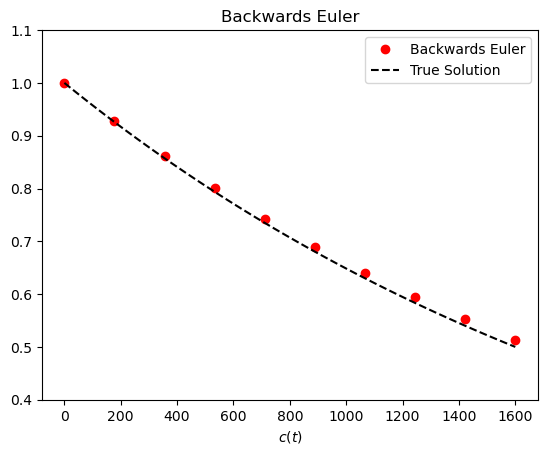

In [10]:
c_0 = 1.0
decay_constant = numpy.log(2.0) / 1600.0
f = lambda t, u: -decay_constant * u

t_exact = numpy.linspace(0.0, 1.6e3, 100)
u_exact = c_0 * numpy.exp(-decay_constant * t_exact)

# Implement backwards Euler
t = numpy.linspace(0.0, 1.6e3, 10)
delta_t = t[1] - t[0]
U = numpy.empty(t.shape)
U[0] = c_0
for n in range(0, t.shape[0] - 1):
    U[n + 1] = U[n] / (1.0 + decay_constant * delta_t)

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(t, U, 'or', label="Backwards Euler")
axes.plot(t_exact, u_exact, 'k--', label="True Solution")

axes.set_title("Backwards Euler")
axes.set_xlabel("t (years)")
axes.set_xlabel("$c(t)$")
axes.set_ylim((0.4,1.1))
axes.legend()
plt.show()

Modifikasi dari metode Euler melibatkan penggunaan titik tengah aproksimasi untuk mengevaluasi 𝑓(𝑡,𝑢), yang dikenal sebagai metode titik tengah (midpoint method). Skemanya dituliskan sebagai
$$ \frac{U^{n+1} - U^{n}}{\Delta t} = f\left(\frac{U^n + U^{n+1}}{2} \right) $$
Metode ini merupakan contoh paling sederhana dari integrator symplectic, yaitu metode numerik yang memiliki sifat khusus dalam menjaga struktur geometris sistem Hamiltonian saat melakukan integrasi jangka panjang.

<>:16: SyntaxWarning: invalid escape sequence '\D'
<>:16: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Ideapad\AppData\Local\Temp\ipykernel_17116\1684998741.py:16: SyntaxWarning: invalid escape sequence '\D'
  axes.text(400, u_np - 0.05, '$\Delta t$', fontsize=16)


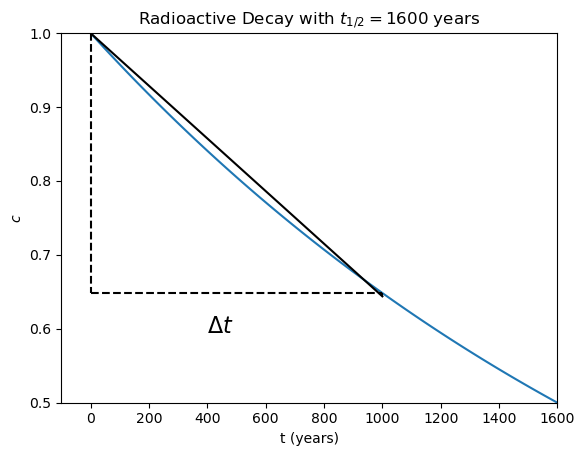

In [11]:
t = numpy.linspace(0.0, 1.6e3, 100)
c_0 = 1.0
decay_constant = numpy.log(2.0) / 1600.0

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(t, c_0 * numpy.exp(-decay_constant * t), label="True Solution")

# Plot Midpoint step
dt = 1e3
u_np = c_0 * (1.0 - decay_constant * dt / 2.0) / (1.0 + decay_constant * dt / 2.0)
axes.plot((0.0, dt), (c_0, u_np), 'k')
axes.plot((dt, dt), (u_np, c_0 * numpy.exp(-decay_constant * dt)), 'k--')
axes.plot((0.0, 0.0), (c_0, c_0 * numpy.exp(-decay_constant * dt)), 'k--')
axes.plot((0.0, dt), (c_0 * numpy.exp(-decay_constant * dt), c_0 * numpy.exp(-decay_constant * dt)), 'k--')
axes.text(400, u_np - 0.05, '$\Delta t$', fontsize=16)

axes.set_title("Radioactive Decay with $t_{1/2} = 1600$ years")
axes.set_xlabel('t (years)')
axes.set_ylabel('$c$')
axes.set_xlim(-1e2, 1.6e3)
axes.set_ylim((0.5,1.0))
plt.show()

Modifikasi pada metode Euler melibatkan penggunaan titik tengah yang diaproksimasi untuk mengevaluasi 𝑓(𝑡,𝑢), yang disebut sebagai metode titik tengah (midpoint method). Skema dari metode ini adalah
$$ \frac{U^{n+1} - U^{n}}{\Delta t} = f\left(\frac{U^n + U^{n+1}}{2} \right) $$

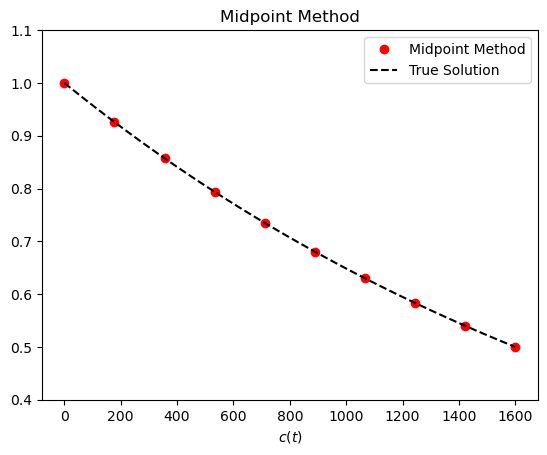

In [12]:
c_0 = 1.0
decay_constant = numpy.log(2.0) / 1600.0
f = lambda t, u: -decay_constant * u

t_exact = numpy.linspace(0.0, 1.6e3, 100)
u_exact = c_0 * numpy.exp(-decay_constant * t_exact)

# Implement midpoint
t = numpy.linspace(0.0, 1.6e3, 10)
delta_t = t[1] - t[0]
U = numpy.empty(t.shape)
U[0] = c_0
integration_constant = (1.0 - decay_constant * delta_t / 2.0) / (1.0 + decay_constant * delta_t / 2.0)
for n in range(0, t.shape[0] - 1):
    U[n + 1] = U[n] * integration_constant

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(t, U, 'or', label="Midpoint Method")
axes.plot(t_exact, u_exact, 'k--', label="True Solution")

axes.set_title("Midpoint Method")
axes.set_xlabel("t (years)")
axes.set_xlabel("$c(t)$")
axes.set_ylim((0.4,1.1))
axes.legend()
plt.show()

Metode implisit sederhana lainnya didasarkan pada pendekatan integral menggunakan metode trapesium (trapezoidal method). Skemanya dituliskan sebagai
$$ \frac{U^{n+1} - U^{n}}{\Delta t} = \frac{1}{2} (f(U^n) + f(U^{n+1})) $$

<>:16: SyntaxWarning: invalid escape sequence '\D'
<>:16: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Ideapad\AppData\Local\Temp\ipykernel_17116\4077898492.py:16: SyntaxWarning: invalid escape sequence '\D'
  axes.text(400, u_np - 0.05, '$\Delta t$', fontsize=16)


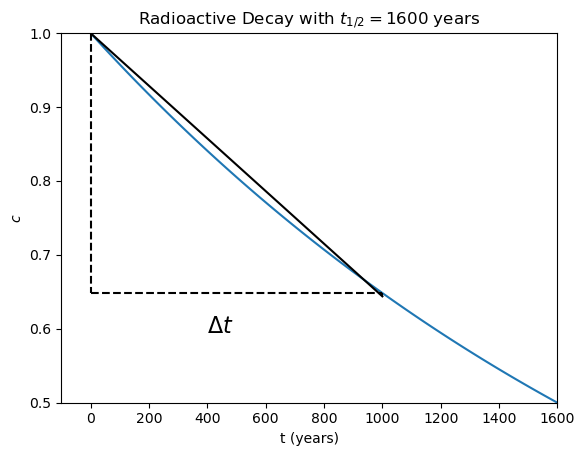

In [13]:
t = numpy.linspace(0.0, 1.6e3, 100)
c_0 = 1.0
decay_constant = numpy.log(2.0) / 1600.0

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(t, c_0 * numpy.exp(-decay_constant * t), label="True Solution")

# Plot Trapezoidal step
dt = 1e3
u_np = c_0 * (1.0 - decay_constant * dt / 2.0) / (1.0 + decay_constant * dt / 2.0)
axes.plot((0.0, dt), (c_0, u_np), 'k')
axes.plot((dt, dt), (u_np, c_0 * numpy.exp(-decay_constant * dt)), 'k--')
axes.plot((0.0, 0.0), (c_0, c_0 * numpy.exp(-decay_constant * dt)), 'k--')
axes.plot((0.0, dt), (c_0 * numpy.exp(-decay_constant * dt), c_0 * numpy.exp(-decay_constant * dt)), 'k--')
axes.text(400, u_np - 0.05, '$\Delta t$', fontsize=16)

axes.set_title("Radioactive Decay with $t_{1/2} = 1600$ years")
axes.set_xlabel('t (years)')
axes.set_ylabel('$c$')
axes.set_xlim(-1e2, 1.6e3)
axes.set_ylim((0.5,1.0))
plt.show()

Sekali lagi, kita terapkan metode trapesium
$$ \frac{U^{n+1} - U^{n}}{\Delta t} = \frac{1}{2} (f(U^n) + f(U^{n+1}))$$
Pertanyaannya: Metode ini setara dengan metode apa, dan mengapa demikian? Apakah kesetaraan ini berlaku secara umum?

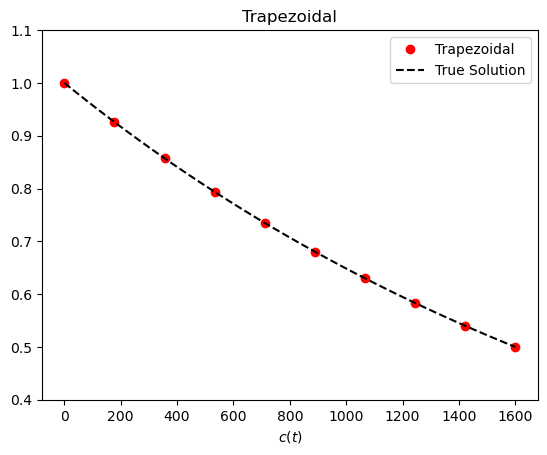

In [14]:
c_0 = 1.0
decay_constant = numpy.log(2.0) / 1600.0
t_exact = numpy.linspace(0.0, 1.6e3, 100)
u_exact = c_0 * numpy.exp(-decay_constant * t_exact)

# Implement trapezoidal method
t = numpy.linspace(0.0, 1.6e3, 10)
delta_t = t[1] - t[0]
U = numpy.empty(t.shape)
U[0] = c_0
integration_constant = (1.0 - decay_constant * delta_t / 2.0) / (1.0 + decay_constant * delta_t / 2.0)
for n in range(t.shape[0] - 1):
    U[n + 1] = U[n] * integration_constant

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(t, U, 'or', label="Trapezoidal")
axes.plot(t_exact, u_exact, 'k--', label="True Solution")

axes.set_title("Trapezoidal")
axes.set_xlabel("t (years)")
axes.set_xlabel("$c(t)$")
axes.set_ylim((0.4,1.1))
axes.legend()
plt.show()

## **Analisis Kesalahan**

### Kesalahan Truncation (Truncation Errors)
Kita dapat mendefinisikan kesalahan truncation (truncation error) seperti yang telah dilakukan sebelumnya, yaitu dengan memasukkan solusi eksak dari ODE ke dalam persamaan beda hingga, lalu mengembangkan menggunakan deret Taylor. Penting di sini untuk menggunakan bentuk beda hingga yang secara langsung mendekati turunan, karena jika tidak, hasilnya bisa berbeda.

Misalkan pendekatan beda hingga untuk turunan dinyatakan sebagai $D(U^{n+1}, U^n, U^{n-1}, \ldots)$ dan skema numerik ditulis dalam bentuk

$$ D(U^{n+1}, U^n, U^{n-1}, \ldots) = F(t^{n+1}, t^n, t^{n-1}, \ldots, U^{n+1}, U^n, U^{n-1}, \ldots) $$

Dimana $F(\cdot)$ mencerminkan bentuk pendekatan terhadap fungsi $f(t, u)$. Maka kesalahan truncation lokal (local truncation error) dapat didefinisikan sebagai
$$ \tau^n = D(u(t^{n+1}), u(t^n), u(t^{n-1}), \ldots) - F(t^{n+1}, t^n, t^{n-1}, \ldots, u(t^{n+1}), u(t^n), u(t^{n-1}), \ldots) $$

Demikian pula, jika diketahui bahwa
$$ \lim_{\Delta t \rightarrow 0} \tau^n = 0 $$
maka persamaan beda hingga tersebut dianggap konsisten (consistent).

Tingkat ketelitian (order of accuracy) juga didefinisikan dengan cara yang sama seperti sebelumnya. Jika
$$ || \tau || \leq C \Delta t^p $$
secara uniform untuk $t \in [0, T]$ maka metode diskretisasi tersebut dikatakan memiliki ketelitian orde-𝑝. Dengan kata lain, kesalahan truncation lokal menurun secara proporsional terhadap Δ𝑡𝑝 saat Δ𝑡→0.  Perlu dicatat bahwa suatu metode disebut konsisten jika $p > 0$.

### Analisis Galat Metode Euler Maju (Forward euler)
Kita bisa menganalisis galat (error) dan orde konvergensi dari metode Euler maju dengan menggunakan deret Taylor yang dikembangkan di sekitar titik  $t_n$:
$$ u(t) = u(t_n) + (t - t_n) u'(t_n) + \frac{u''(t_n)}{2} (t - t_n)^2 + \mathcal{O}((t-t_n)^3)$$
Selanjutnya, kita akan mencoba menghitung galat truncation lokal (LTE) untuk metode Euler maju berdasarkan ekspansi ini.

Dengan mengevaluasi deret Taylor di titik $t_{n+1}$ kita memperoleh
$$\begin{aligned}
u(t_{n+1}) &= u(t_n) + (t_{n+1} - t_n) u'(t_n) + \frac{u''(t_n)}{2} (t_{n+1} - t_n)^2 + \mathcal{O}((t_{n+1}-t_n)^3)\\
&=u(t_n) + \Delta t f(t_n, u(t_n)) + \frac{u''(t_n)}{2} \Delta t^2 + \mathcal{O}(\Delta t^3)
\end{aligned}$$

Berdasarkan definisi galat truncation (truncation error), kita dapat menggunakan ekspansi deret Taylor sebelumnya dan menghitung galat truncation sebagai berikut
$$\begin{aligned}
    \tau^n &= \frac{u(t_{n+1}) - u(t_n)}{\Delta t} - f(t_n, u(t_n)) \\
    &= \frac{1}{\Delta t} \left [u(t_n) + \Delta t ~ f(t_n, u(t_n)) + \frac{u''(t_n)}{2} \Delta t^2 + \mathcal{O}(\Delta t^3) - u(t_n) - \Delta t ~ f(t_n, u(t_n)) \right ]\\
    &= \frac{1}{\Delta t} \left [ \frac{u''(t_n)}{2} \Delta t^2 + \mathcal{O}(\Delta t^3) \right ] \\
    &= \frac{u''(t_n)}{2} \Delta t + \mathcal{O}(\Delta t^2)
\end{aligned}$$
Hasil ini menunjukkan bahwa metode Euler maju (Forward Euler) memiliki galat truncation yang berorde satu, sehingga metode ini bersifat konsisten dan akurasi orde satu.

### Analisis Galat untuk Metode Leap-Frog
Untuk menganalisis metode ini dengan mudah, kita perlu memperluas deret Taylor sebelumnya hingga ke orde yang lebih tinggi, dan mengevaluasinya di dua titik yang dibutuhkan. Deret Taylor dari solusi eksak u(t) dikembangkan di sekitar $𝑡_𝑛$
$$  u(t) = u(t_n) + (t - t_n) u'(t_n) + (t - t_n)^2 \frac{u''(t_n)}{2}  + (t - t_n)^3 \frac{u'''(t_n)}{6} + \mathcal{O}((t-t_n)^4)$$
Dengan mengevaluasi ekspansi tersebut di titik, kita peroleh:
$$\begin{aligned}
u(t_{n+1}) &= u(t_n) + \Delta t f_n + \Delta t^2 \frac{u''(t_n)}{2}  + \Delta t^3 \frac{u'''(t_n)}{6} + \mathcal{O}(\Delta t^4)\\
u(t_{n-1}) &= u(t_n) - \Delta t f_n + \Delta t^2 \frac{u''(t_n)}{2}  - \Delta t^3 \frac{u'''(t_n)}{6} + \mathcal{O}(\Delta t^4)
\end{aligned}$$
Sekarang, coba hitung galat truncation lokal (LTE) untuk metode Leap-Frog menggunakan ekspansi ini

Dengan memasukkan ekspansi Taylor ke dalam definisi galat truncation lokal (LTE) bersama dengan formulasi metode leap-frog, kita peroleh
$$\begin{aligned}
    \tau^n &= \frac{u(t_{n+1}) - u(t_{n-1})}{2 \Delta t} - f(t_n, u(t_n)) \\
    &=\frac{1}{\Delta t} \left[\frac{1}{2}\left( u(t_n) + \Delta t f_n + \Delta t^2 \frac{u''(t_n)}{2}  + \Delta t^3 \frac{u'''(t_n)}{6} + \mathcal{O}(\Delta t^4)\right) \right . \\
    &\quad \quad\left . - \frac{1}{2} \left ( u(t_n) - \Delta t f_n + \Delta t^2 \frac{u''(t_n)}{2}  - \Delta t^3 \frac{u'''(t_n)}{6} + \mathcal{O}(\Delta t^4)\right ) - \Delta t~ f(t_n, u(t_n)) \right ] \\
    &= \frac{1}{\Delta t} \left [\Delta t^3 \frac{u'''(t_n)}{6} + \mathcal{O}(\Delta t^5)\right ] \\
    &= \Delta t^2 \frac{u'''(t_n)}{6} + \mathcal{O}(\Delta t^4)
\end{aligned}$$
Jadi, metode Leap-Frog memiliki akurasi orde kedua (second-order accurate) dan konsisten.

<>:68: SyntaxWarning: invalid escape sequence '\D'
<>:68: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Ideapad\AppData\Local\Temp\ipykernel_17116\962851498.py:68: SyntaxWarning: invalid escape sequence '\D'
  axes.set_xlabel("$\Delta t$")


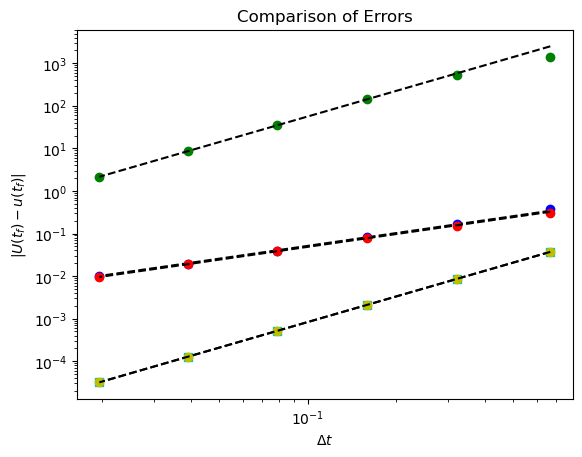

In [15]:
# Compare accuracy between Euler and Leap-Frog
f = lambda t, u: -u
u_exact = lambda t: numpy.exp(-t)
u_0 = 1.0

t_f = 10.0
num_steps = [2**n for n in range(4,10)]
delta_t = numpy.empty(len(num_steps))
error = numpy.empty((5, len(num_steps)))

for (i, N) in enumerate(num_steps):
    t = numpy.linspace(0, t_f, N)
    delta_t[i] = t[1] - t[0]
    
    # Note that in the cases below we can instantiate this array now
    # rather than every time as none of the implicit methods require
    # the space to store the future solution
    U = numpy.empty(t.shape)
    
    # Compute ForwardEuler solution
    U[0] = u_0
    for n in range(t.shape[0] - 1):
        U[n+1] = U[n] + delta_t[i] * f(t[n], U[n])
    error[0, i] = numpy.linalg.norm(delta_t[i] * (U - u_exact(t)), ord=1)
        
    # Compute Leap-Frog
    U[0] = u_0
    U[1] = U[0] + delta_t[i] * f(t[0], U[0])
    for n in range(1, t.shape[0] - 1):
        U[n+1] = U[n-1] + 2.0 * delta_t[i] * f(t[n], U[n])
    error[1, i] = numpy.linalg.norm(delta_t[i] * (U - u_exact(t)), ord=1)
    
    # Compute Backward Euler
    U[0] = u_0
    for n in range(0, t.shape[0] - 1):
        U[n + 1] = U[n] / (1.0 + delta_t[i])
    error[2, i] = numpy.linalg.norm(delta_t[i] * (U - u_exact(t)), ord=1)
    
    # Compute mid-pointU[0] = c_0
    U[0] = u_0
    integration_constant = (1.0 - delta_t[i] / 2.0) / (1.0 + delta_t[i] / 2.0)
    for n in range(0, t.shape[0] - 1):
        U[n + 1] = U[n] * integration_constant
    error[3, i] = numpy.linalg.norm(delta_t[i] * (U - u_exact(t)), ord=1)
    
    # Compute trapezoidal
    U[0] = u_0
    integration_constant = (1.0 - delta_t[i] / 2.0) / (1.0 + delta_t[i] / 2.0)
    for n in range(t.shape[0] - 1):
        U[n + 1] = U[n] * integration_constant
    error[4, i] = numpy.linalg.norm(delta_t[i] * (U - u_exact(t)), ord=1)
    
# Plot error vs. delta_t
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

order_C = lambda delta_x, error, order: numpy.exp(numpy.log(error) - order * numpy.log(delta_x))
style = ['bo', 'go', 'ro', 'cs', 'yo']
label = ['Forward Euler', "Leap-Frog", "Backward Euler", "Mid-Point", "Trapezoidal"]
order = [1, 2, 1, 2, 2]

for k in range(5):
    axes.loglog(delta_t, error[k, :], style[k], label=label[k])
    axes.loglog(delta_t, order_C(delta_t[2], error[k, 2], order[k]) * delta_t**order[k], 'k--')

# axes.legend(loc=2)
axes.set_title("Comparison of Errors")
axes.set_xlabel("$\Delta t$")
axes.set_ylabel("$|U(t_f) - u(t_f)|$")

plt.show()

### Galat Truncation Satu Langkah (One-Step Error)

Ada definisi lain dari galat truncation lokal yang kadang digunakan dalam metode numerik ODE, yang disebut galat satu langkah (one-step error), yang sedikit berbeda dari definisi galat truncation lokal yang kita gunakan sebelumnya. Definisi kita menggunakan diskretisasi langsung dari turunan untuk menemukan galat truncation lokal, sementara alternatif ini mendasarkan galat pada bentuk yang terlihat seperti memperbarui nilai sebelumnya.

Sebagai contoh, pertimbangkan metode leap-frog, di mana galat truncation lokal (LTE) yang kita temukan sebelumnya didasarkan pada
$$ \frac{U_{n+1} - U_{n-1}}{2 \Delta t} = f(U_n)$$
yang menghasilkan LTE orde kedua.

Untuk galat satu langkah, kita mempertimbangkan
$$ U_{n+1} = U_{n-1} + 2 \Delta t f(U_n) $$
yang menghasilkan galat satu langkah $\mathcal{O}(\Delta t^3)$!
$$\begin{aligned}
    \mathcal{L}^n &= u(t_{n+1}) - u(t_{n-1}) - 2 \Delta t f(u(t_n)) \\
    &= \frac{1}{3} \Delta t^3 u'''(t_n) + \mathcal{O}(\Delta t^5) \\
    &= 2 ~\Delta t ~\tau^n.
\end{aligned}$$

Galat satu langkah ini dinamakan demikian untuk menunjukkan bahwa ini mungkin adalah galat untuk satu langkah waktu, sedangkan galat global dapat lebih tinggi. Untuk tetap konsisten dengan pembahasan sebelumnya mengenai konvergensi, kita akan terus menggunakan definisi LTE yang kita pakai sebelumnya. Kita akan menunjukkan bahwa dengan definisi stabilitas yang tepat dan LTE orde $p$, kita dapat mengharapkan galat global orde $p$. Secara umum, untuk galat satu langkah orde $p+1$, galat global akan menjadi orde $p$.

### **Metode  Deret Taylor (Taylor Series)**

Metode deret Taylor dapat diturunkan dengan menggantikan langsung fungsi sisi kanan $f(t, u)$ dan turunan yang sesuai ke dalam ekspansi deret Taylor untuk $u(t_{n+1})$. Untuk metode orde $p$, kita akan melihat deret Taylor hingga orde tersebut dan menggantikan semua turunan dari $u$ dengan turunan dari $f$.

Untuk kasus umum, kita memiliki
$$\begin{aligned}
    u(t_{n+1}) = u(t_n) + \Delta t u'(t_n) + \frac{\Delta t^2}{2} u''(t_n) + \frac{\Delta t^3}{6} u'''(t_n) + \cdots + \frac{\Delta t^p}{p!} u^{(p)}(t_n)
\end{aligned}$$
yang berisi turunan dari $u$ hingga orde $p$. Kemudian kita menggantikan turunan-turunan ini dengan turunan yang sesuai dari $f$, yang akan selalu satu kurang dari turunan $u$ (karena persamaan ODE asli), yaitu
$$  u^{(p)}(t_n) = f^{(p-1)}(t_n, u(t_n)) $$
sehingga menghasilkan metode
$$  u(t_{n+1}) = u(t_n) + \Delta t f(t_n, u(t_n)) + \frac{\Delta t^2}{2} f'(t_n, u(t_n)) + \frac{\Delta t^3}{6} f''(t_n, u(t_n)) + \cdots + \frac{\Delta t^p}{p!} f^{(p-1)}(t_n, u(t_n))$$

Kekurangan dari metode ini adalah kita harus membuat metode baru setiap kali kita memiliki fungsi $f$ yang baru, dan kita juga memerlukan $p-1$ turunan dari $f$.

### Metode Deret Taylor Orde 2 (2nd Order Taylor Series Method)
Kita ingin menggunakan suku hingga orde kedua, sehingga kita perlu mengambil turunan pertama dari $u' = f(t, u)$ untuk menemukan $u'' = f'(t, u)$. Cobalah untuk mengembangkan metode ini.

\begin{align*}
    u(t_{n+1}) &= u(t_n) + \Delta t u'(t_n) + \frac{\Delta t^2}{2} u''(t_n) \\
    &=u(t_n) + \Delta t f(t_n, u(t_n)) + \frac{\Delta t^2}{2} f'(t_n, u(t_n)) \quad \text{or} \\
    U^{n+1} &= U^n + \Delta t f(t_n, U^n) + \frac{\Delta t^2}{2} f'(t_n, U^n).
\end{align*}

### **Metode Runge-Kutta (Runge-Kutta Methods)**
Salah satu cara untuk mengembangkan penyelesai ODE dengan orde yang lebih tinggi adalah dengan menghitung tahap-tahap antara. Ini bukan metode multi-step karena masih hanya memerlukan informasi dari langkah waktu saat ini, tetapi mereka meningkatkan orde akurasi dengan menambahkan tahap-tahap. Jenis metode ini disebut metode Runge-Kutta.

#### Contoh: Metode Runge-Kutta Dua Tahap

Ide dasar di balik metode Runge-Kutta dua tahap yang paling sederhana adalah untuk memperkirakan solusi pada $ t_n + \Delta t / 2 $  menggunakan metode Euler dan menggunakannya dalam evaluasi fungsi untuk pembaruan akhir.
$$
\begin{aligned}
    U^* &= U^n + \frac{1}{2} \Delta t f(U^n) \\
    U^{n+1} &= U^n + \Delta t f(U^*) = U^n + \Delta t f(U^n + \frac{1}{2} \Delta t f(U^n))
\end{aligned}
$$

Truncation error dapat dihitung dengan cara yang serupa seperti yang kita lakukan sebelumnya, namun kita perlu memperhitungkan cara untuk menghitung turunan di dalam fungsi. Perhatikan bahwa karena
$$ 
f(u(t_n)) = u'(t_n)
$$ 
mendiferensiasi ini menghasilkan
$$
 f'(u(t_n)) u'(t_n) = u''(t_n)
$$
sehingga mengahsilkan
$$\begin{aligned}
    f\left(u(t_n) + \frac{1}{2} \Delta t f(u(t_n)) \right ) &= f\left(u(t_n) +\frac{1}{2} \Delta t u'(t_n) \right ) \\
    &= f(u(t_n)) + \frac{1}{2} \Delta t u'(t_n) f'(u(t_n)) + \frac{1}{8} \Delta t^2 (u'(t_n))^2 f''(u(t_n)) + \mathcal{O}(\Delta t^3) \\
    &=u'(t_n) + \frac{1}{2} \Delta t u''(t_n) + \mathcal{O}(\Delta t^2)
\end{aligned}$$


Kembali ke kesalahan pemangkasan (truncation error), kita memiliki
$$\begin{aligned}
    \tau^n &= \frac{1}{\Delta t} \left[u(t_n) + \Delta t f\left(u(t_n) + \frac{1}{2} \Delta t f(u(t_n))\right) - \left(u(t_n) + \Delta t f(t_n, u(t_n)) + \frac{u''(t_n)}{2} \Delta t^2 + \mathcal{O}(\Delta t^3) \right ) \right] \\
    &=\frac{1}{\Delta t} \left[\Delta t u'(t_n) + \frac{1}{2} \Delta t^2 u''(t_n) + \mathcal{O}(\Delta t^3) - \Delta t u'(t_n) - \frac{u''(t_n)}{2} \Delta t^2 + \mathcal{O}(\Delta t^3) \right] \\
    &= \mathcal{O}(\Delta t^2)
\end{aligned}$$
Jadi metode ini adalah metode yang akurat orde kedua.

#### Contoh: Metode Runge-Kutta 4 tahap

$\begin{aligned}
    Y_1 &= U^n \\
    Y_2 &= U^n + \frac{1}{2} \Delta t f(Y_1, t_n) \\
    Y_3 &= U^n + \frac{1}{2} \Delta t f(Y_2, t_n + \Delta t / 2) \\
    Y_4 &= U^n + \Delta t f(Y_3, t_n + \Delta t / 2) \\
    U^{n+1} &= U^n + \frac{\Delta t}{6} \left [f(Y_1, t_n) + 2 f(Y_2, t_n + \Delta t / 2) + 2 f(Y_3, t_n + \Delta t/2) + f(Y_4, t_n + \Delta t) \right ]
\end{aligned}$

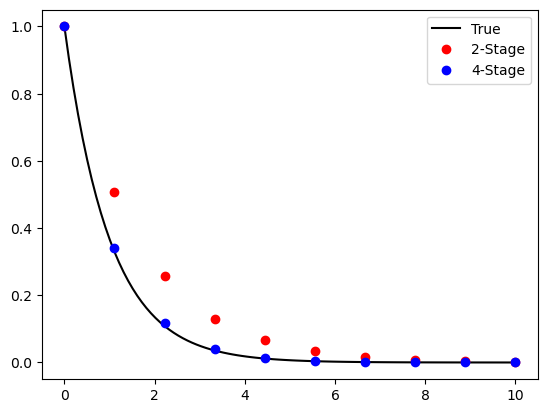

In [16]:
# Import library yang dibutuhkan
import numpy
import matplotlib.pyplot as plt

# Definisikan fungsi f(t, u) = -u
f = lambda t, u: -u

# Buat solusi eksak u(t) = exp(-t) sebagai pembanding
t_exact = numpy.linspace(0.0, 10.0, 100)  # 100 titik dari 0 sampai 10
u_exact = numpy.exp(-t_exact)            # solusi eksak u(t) = e^(-t)

# Inisialisasi parameter numerik
N = 10                                    # jumlah langkah
t = numpy.linspace(0, 10.0, N)            # titik waktu dari 0 ke 10 sebanyak N titik
delta_t = t[1] - t[0]                     # ukuran langkah waktu

# ------------------------- Metode Runge-Kutta orde 2 (RK2) -------------------------
U_2 = numpy.empty(t.shape)                # array solusi numerik RK2
U_2[0] = 1.0                              # kondisi awal u(0) = 1
for (n, t_n) in enumerate(t[1:]):
    # Proses RK2 (seharusnya ini implementasi Heun, tapi salah di sini)
    U_2[n+1] = U_2[n] + 0.5 * delta_t * f(t_n, U_2[n])               # langkah awal (keliru)
    U_2[n+1] = U_2[n] + delta_t * f(t_n + 0.5 * delta_t, U_2[n+1])   # pembaruan (gandakan update -> salah)
# Catatan: Implementasi RK2 ini tidak benar, seharusnya pakai prediksi dan koreksi (lihat perbaikan di bawah)

# ------------------------- Metode Runge-Kutta orde 4 (RK4) -------------------------
U_4 = numpy.empty(t.shape)                # array solusi numerik RK4
U_4[0] = 1.0                              # kondisi awal u(0) = 1
for (n, t_n) in enumerate(t[1:]):
    y_1 = U_4[n]
    y_2 = U_4[n] + 0.5 * delta_t * f(t_n, y_1)
    y_3 = U_4[n] + 0.5 * delta_t * f(t_n + 0.5 * delta_t, y_2)
    y_4 = U_4[n] + delta_t * f(t_n + 0.5 * delta_t, y_3)
    # Kombinasi semua slope
    U_4[n+1] = U_4[n] + delta_t / 6.0 * (
        f(t_n, y_1) +
        2.0 * f(t_n + 0.5 * delta_t, y_2) +
        2.0 * f(t_n + 0.5 * delta_t, y_3) +
        f(t_n + delta_t, y_4)
    )

# ------------------------- Plot hasilnya -------------------------
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

# Plot solusi eksak dan numerik
axes.plot(t_exact, u_exact, 'k', label="True")  # garis hitam = eksak
axes.plot(t, U_2, 'ro', label="2-Stage")        # titik merah = RK2
axes.plot(t, U_4, 'bo', label="4-Stage")        # titik biru = RK4
axes.legend(loc=1)                              # tampilkan legenda

plt.show()                                      # tampilkan grafik


<>:81: SyntaxWarning: invalid escape sequence '\D'
<>:81: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Ideapad\AppData\Local\Temp\ipykernel_17116\3509944373.py:81: SyntaxWarning: invalid escape sequence '\D'
  axes.set_xlabel("$\Delta t$")


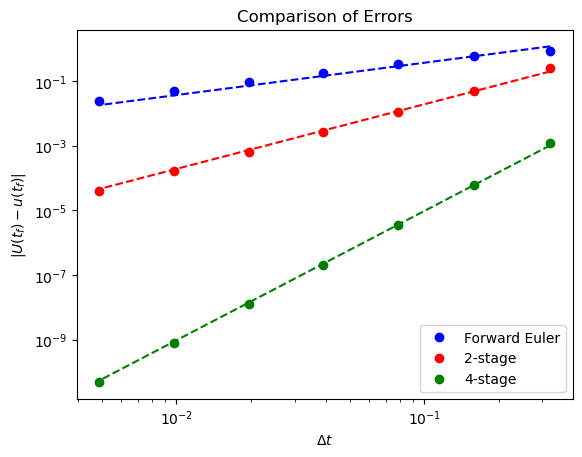

In [17]:
# Import library yang diperlukan
import numpy
import matplotlib.pyplot as plt

# Definisikan fungsi f(t, u) = -u
f = lambda t, u: -u

# Solusi eksak u(t) = e^(-t)
u_exact = lambda t: numpy.exp(-t)

# Parameter waktu akhir
t_f = 10.0

# Jumlah langkah N yang akan digunakan (dari 2^5 sampai 2^11)
num_steps = [2**n for n in range(5,12)]

# Siapkan array kosong untuk menyimpan hasil
delta_t = numpy.empty(len(num_steps))     # ukuran langkah
error_euler = numpy.empty(len(num_steps)) # error metode Euler
error_2 = numpy.empty(len(num_steps))     # error RK2
error_4 = numpy.empty(len(num_steps))     # error RK4

# Loop untuk tiap N (jumlah langkah)
for (i, N) in enumerate(num_steps):
    t = numpy.linspace(0, t_f, N)           # titik waktu
    delta_t[i] = t[1] - t[0]                # ukuran langkah untuk N
    
    # ---------------- Metode Euler ----------------
    U_euler = numpy.empty(t.shape)
    U_euler[0] = 1.0
    for (n, t_n) in enumerate(t[1:]):
        U_euler[n+1] = U_euler[n] + delta_t[i] * f(t_n, U_euler[n])

    # ---------------- Metode RK2 (Catatan: implementasi kurang tepat) ----------------
    U_2 = numpy.empty(t.shape)
    U_2[0] = 1.0
    for (n, t_n) in enumerate(t[1:]):
        # Dua kali update salah (sebaiknya pakai metode Heun, lihat catatan bawah)
        U_2[n+1] = U_2[n] + 0.5 * delta_t[i] * f(t_n, U_2[n])
        U_2[n+1] = U_2[n] + delta_t[i] * f(t_n, U_2[n+1])

    # ---------------- Metode RK4 ----------------
    U_4 = numpy.empty(t.shape)
    U_4[0] = 1.0
    for (n, t_n) in enumerate(t[1:]):
        y_1 = U_4[n]
        y_2 = U_4[n] + 0.5 * delta_t[i] * f(t_n, y_1)
        y_3 = U_4[n] + 0.5 * delta_t[i] * f(t_n + 0.5 * delta_t[i], y_2)
        y_4 = U_4[n] + delta_t[i] * f(t_n + 0.5 * delta_t[i], y_3)
        U_4[n+1] = U_4[n] + delta_t[i] / 6.0 * (
            f(t_n, y_1) +
            2.0 * f(t_n + 0.5 * delta_t[i], y_2) +
            2.0 * f(t_n + 0.5 * delta_t[i], y_3) +
            f(t_n + delta_t[i], y_4)
        )

    # Hitung galat relatif akhir
    exact_final = u_exact(t_f)
    error_euler[i] = abs(U_euler[-1] - exact_final) / abs(exact_final)
    error_2[i] = abs(U_2[-1] - exact_final) / abs(exact_final)
    error_4[i] = abs(U_4[-1] - exact_final) / abs(exact_final)

# ---------------- Plot Galat vs. Δt ----------------
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

# Plot log-log error untuk ketiga metode
axes.loglog(delta_t, error_euler, 'bo', label='Forward Euler')
axes.loglog(delta_t, error_2, 'ro', label='2-stage')
axes.loglog(delta_t, error_4, 'go', label="4-stage")

# Tambahkan garis referensi untuk ordo error
order_C = lambda delta_x, error, order: numpy.exp(numpy.log(error) - order * numpy.log(delta_x))
axes.loglog(delta_t, order_C(delta_t[1], error_euler[1], 1.0) * delta_t**1.0, '--b')  # Orde 1
axes.loglog(delta_t, order_C(delta_t[1], error_2[1], 2.0) * delta_t**2.0, '--r')      # Orde 2
axes.loglog(delta_t, order_C(delta_t[1], error_4[1], 4.0) * delta_t**4.0, '--g')      # Orde 4

# Label dan judul
axes.legend(loc=4)
axes.set_title("Comparison of Errors")
axes.set_xlabel("$\Delta t$")
axes.set_ylabel("$|U(t_f) - u(t_f)|$")

plt.show()

### **Metode Multi-Step Linear**
Metode multi-step (seperti yang diperkenalkan melalui metode leap-frog) adalah metode ODE yang memerlukan evaluasi beberapa langkah waktu untuk bekerja. 
Beberapa keuntungan menggunakan metode multi-step dibandingkan metode satu langkah meliputi:
- Metode deret Taylor memerlukan diferensiasi persamaan yang diberikan, yang bisa menjadi rumit dan sulit untuk diterapkan.
- Metode satu langkah pada orde lebih tinggi sering memerlukan evaluasi fungsi 𝑓 berkali-kali.

Kekurangan:
- Metode ini tidak dapat memulai secara mandiri, yaitu mereka memerlukan metode lain untuk menemukan nilai awal.
- Langkah waktu Δ𝑡 dalam metode satu langkah bisa diubah kapan saja, sementara dalam metode multi-step ini jauh lebih kompleks.

### Metode Multi-Step Linear Umum
Semua metode multi-step linear dapat dituliskan sebagai kombinasi linear dari solusi masa lalu, sekarang, dan masa depan

$$ \sum^r_{j=0} \alpha_j U^{n+j} = \Delta t \sum^r_{j=0} \beta_j f(U^{n+j}, t_{n+j})$$

Jika $\beta_r = 0$ maka metode tersebut adalah eksplisit (hanya memerlukan langkah waktu sebelumnya). Perlu dicatat bahwa koefisien-koefisiennya tidak unik karena kita dapat mengalikan kedua sisi dengan sebuah konstanta. Dalam praktiknya, normalisasi $\alpha_r = 1$ digunakan.

#### Contoh: Metode Adams

$$  U^{n+r} = U^{n+r-1} + \Delta t \sum^r_{j=0} \beta_j f(U^{n+j})$$
Semua metode ini memiliki  $\alpha_r = 1$, $\alpha_{r-1} = -1$ dan $\alpha_j=0$ untuk $j < r - 1$ sehingga metode ini ditentukan oleh bagaimana evaluasi dari $f$ dilakukan, yang menentukan nilai $\beta_j$.


### Metode Adams-Bashforth (Adams-Bashforth Methods)
Metode Adams-Bashforth adalah penyelesai eksplisit yang memaksimalkan tingkat akurasi yang diberikan berdasarkan jumlah langkah $r$.  Ini dicapai dengan melihat deret Taylor dan memilih koefisien $\beta_j$  untuk menghilangkan sebanyak mungkin suku dalam deret Taylor
$$\begin{aligned}
    \text{1-step:} & & U_{n+1} &= U_n +\Delta t f(U_n) \\
    \text{2-step:} & & U_{n+2} &= U_{n+1} + \frac{\Delta t}{2} (-f(U_n) + 3 f(U_{n+1})) \\
    \text{3-step:} & & U_{n+3} &= U_{n+2} + \frac{\Delta t}{12} (5 f(U_n) - 16 f(U_{n+1}) + 23 f(U_{n+2})) \\
    \text{4-step:} & & U_{n+4} &= U_{n+3} + \frac{\Delta t}{24} (-9 f(U_n) + 37 f(U_{n+1}) -59 f(U_{n+2}) + 55 f(U_{n+3}))
\end{aligned}$$

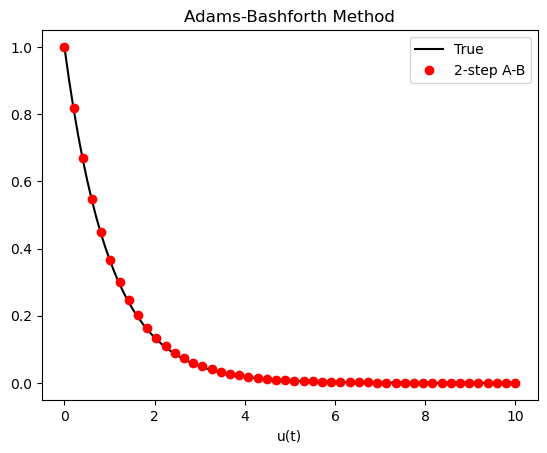

In [18]:
# Use 2-step Adams-Bashforth to compute solution
f = lambda t, u: -u

t_exact = numpy.linspace(0.0, 10.0, 100)
u_exact = numpy.exp(-t_exact)

N = 50
t = numpy.linspace(0, 10.0, N)
delta_t = t[1] - t[0]
U = numpy.empty(t.shape)

# Use RK-2 to start the method
U[0] = 1.0
U[1] = U[0] + 0.5 * delta_t * f(t[0], U[0])
U[1] = U[0] + delta_t * f(t[0], U[1])
for n in range(0,len(t)-2):
    U[n+2] = U[n + 1] + delta_t / 2.0 * (-f(t[n], U[n]) + 3.0 * f(t[n+1], U[n+1]))
    
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

axes.plot(t_exact, u_exact, 'k', label="True")
axes.plot(t, U, 'ro', label="2-step A-B")

axes.set_title("Adams-Bashforth Method")
axes.set_xlabel("t")
axes.set_xlabel("u(t)")
axes.legend(loc=1)

plt.show()

### Metode Adams-Moulton (Adams-Moulton Methods)
Metode Adams-Moulton adalah versi implisit dari metode Adams-Bashforth. Karena ini memberikan satu parameter tambahan untuk digunakan $\beta_r$, metode ini umumnya memiliki tingkat akurasi satu orde lebih tinggi daripada rekan-rekannya.
$$\begin{aligned}
    \text{1-step:} &  & U_{n+1} &= U_n + \frac{\Delta t}{2} (f(U_n) + f(U_{n+1})) \\
    \text{2-step:} &  & U_{n+2} &= U_{n+1} + \frac{\Delta t}{12} (-f(U_n) + 8f(U_{n+1}) + 5f(U_{n+2})) \\
    \text{3-step:} &  & U_{n+3} &= U_{n+2} + \frac{\Delta t}{24} (f(U_n) - 5f(U_{n+1}) + 19f(U_{n+2}) + 9f(U_{n+3})) \\
    \text{4-step:} &  & U_{n+4} &= U_{n+3} + \frac{\Delta t}{720}(-19 f(U_n) + 106 f(U_{n+1}) -264 f(U_{n+2}) + 646 f(U_{n+3}) + 251 f(U_{n+4}))
\end{aligned}$$

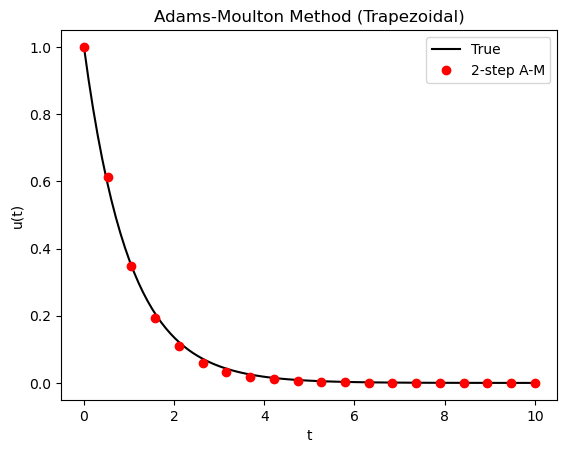

In [19]:
import numpy
import matplotlib.pyplot as plt

# u' = - decay_constant * u
decay_constant = 1.0
f = lambda t, u: -decay_constant * u

# Solusi eksak
t_exact = numpy.linspace(0.0, 10.0, 100)
u_exact = numpy.exp(-decay_constant * t_exact)

# Grid waktu
N = 20
t = numpy.linspace(0, 10.0, N)
delta_t = t[1] - t[0]
U = numpy.empty(t.shape)

# Inisialisasi solusi
U[0] = 1.0

# Gunakan RK2 untuk inisialisasi U[1]
k1 = f(t[0], U[0])
k2 = f(t[0] + delta_t, U[0] + delta_t * k1)
U[1] = U[0] + 0.5 * delta_t * (k1 + k2)

# Iterasi dengan metode AB2-AM2 (Prediktor–Korektor)
for n in range(1, len(t) - 1):
    # Prediktor: AB2
    U_pred = U[n] + delta_t / 2.0 * (3 * f(t[n], U[n]) - f(t[n - 1], U[n - 1]))

    # Korektor: AM2 (Trapezoidal rule)
    U[n + 1] = U[n] + delta_t / 2.0 * (f(t[n], U[n]) + f(t[n + 1], U_pred))

# Plot hasil
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

axes.plot(t_exact, u_exact, 'k', label="True")   # Solusi eksak
axes.plot(t, U, 'ro', label="2-step A-M")        # Solusi numerik

axes.set_title("Adams-Moulton Method (Trapezoidal)")
axes.set_xlabel("t")
axes.set_ylabel("u(t)")
axes.legend(loc=1)

plt.show()

### Truncation Error untuk Metode Multi-Langkah
Kita dapat kembali menemukan kesalahan pemotongan (truncation error) secara umum untuk metode multi-langkah linier
$$\begin{aligned}
    \tau^n &= \frac{1}{\Delta t} \left [\sum^r_{j=0} \alpha_j u(t_{n+j}) - \Delta t \sum^r_{j=0} \beta_j f(t_{n+j}, u(t_{n+j})) \right ]
\end{aligned}$$

Dengan menggunakan ekspansi umum dan evaluasi deret Taylor di sekitar $t_n$, kita memperoleh
$$\begin{aligned}
    u(t_{n+j}) &= u(t_n) + j \Delta t u'(t_n) + \frac{1}{2} (j \Delta t)^2 u''(t_n) + \mathcal{O}(\Delta t^3) \\
    u'(t_{n+j}) &= u'(t_n) + j \Delta t u''(t_n) + \frac{1}{2} (j \Delta t)^2 u'''(t_n) + \mathcal{O}(\Delta t^3)
\end{aligned}$$
Yang mengarah pada ekspresi kesalahan pemotongan sebagai berikut
$$\begin{aligned}
\tau^n &= \frac{1}{\Delta t}\left( \sum^r_{j=0} \alpha_j\right) u(t_{n}) + \left(\sum^r_{j=0} (j\alpha_j - \beta_j)\right) u'(t_n) + \Delta t \left(\sum^r_{j=0} \left (\frac{1}{2}j^2 \alpha_j - j \beta_j \right) \right) u''(t_n) \\
&\quad \quad + \cdots + \Delta t^{q - 1} \left (\frac{1}{q!} \left(j^q \alpha_j - \frac{1}{(q-1)!} j^{q-1} \beta_j \right) \right) u^{(q)}(t_n) + \cdots
\end{aligned}$$


Metode ini disebut konsisten jika dua suku pertama dari ekspansi hilang, yaitu
$$ 
\sum^r_{j=0} \alpha_j = 0 
$$ 
dan 
$$ 
\sum^r_{j=0} j \alpha_j = \sum^r_{j=0} \beta_j 
$$

<>:57: SyntaxWarning: invalid escape sequence '\D'
<>:57: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Ideapad\AppData\Local\Temp\ipykernel_17116\3576784995.py:57: SyntaxWarning: invalid escape sequence '\D'
  axes.set_xlabel("$\Delta t$")


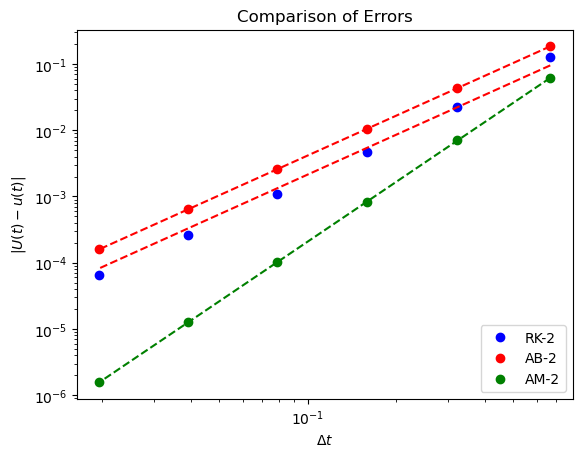

In [20]:
# Compare accuracy between RK-2, AB-2 and AM-2
f = lambda t, u: -u
u_exact = lambda t: numpy.exp(-t)

t_f = 10.0
num_steps = [2**n for n in range(4,10)]
delta_t = numpy.empty(len(num_steps))
error_rk = numpy.empty(len(num_steps))
error_ab = numpy.empty(len(num_steps))
error_am = numpy.empty(len(num_steps))

for (i, N) in enumerate(num_steps):
    t = numpy.linspace(0, t_f, N)
    delta_t[i] = t[1] - t[0]
        
    # Compute RK2
    U_rk = numpy.empty(t.shape)
    U_rk[0] = 1.0
    for n in range(t.shape[0]-1):
        U_rk[n+1] = U_rk[n] + 0.5 * delta_t[i] * f(t[n], U_rk[n])
        U_rk[n+1] = U_rk[n] + delta_t[i] * f(t[n], U_rk[n+1])
        
    # Compute Adams-Bashforth 2-stage
    U_ab = numpy.empty(t.shape)
    U_ab[:2] = U_rk[:2]
    for n in range(t.shape[0] - 2):
        U_ab[n+2] = U_ab[n + 1] + delta_t[i] / 2.0 * (-f(t[n], U_ab[n]) + 3.0 * f(t[n+1], U_ab[n+1]))
    
    # Compute Adama-Moulton 2-stage
    U_am = numpy.empty(t.shape)
    U_am[:2] = U_rk[:2]
    decay_constant = 1.0
    integration_constant = 1.0 / (1.0 + 5.0 * decay_constant * delta_t[i] / 12.0)
    for n in range(t.shape[0] - 2):
        U_am[n+2] = (U_am[n+1] + decay_constant * delta_t[i] / 12.0 * (U_am[n] - 8.0 * U_am[n+1])) * integration_constant
        
    # Compute error for each
    error_rk[i] = numpy.linalg.norm(delta_t[i] * (U_rk - u_exact(t)), ord=1)
    error_ab[i] = numpy.linalg.norm(delta_t[i] * (U_ab - u_exact(t)), ord=1)
    error_am[i] = numpy.linalg.norm(delta_t[i] * (U_am - u_exact(t)), ord=1)
    
# Plot error vs. delta_t
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

axes.loglog(delta_t, error_rk, 'bo', label='RK-2')
axes.loglog(delta_t, error_ab, 'ro', label='AB-2')
axes.loglog(delta_t, error_am, 'go', label="AM-2")

order_C = lambda delta_x, error, order: numpy.exp(numpy.log(error) - order * numpy.log(delta_x))
axes.loglog(delta_t, order_C(delta_t[1], error_rk[1], 2.0) * delta_t**2.0, '--r')
axes.loglog(delta_t, order_C(delta_t[1], error_ab[1], 2.0) * delta_t**2.0, '--r')
axes.loglog(delta_t, order_C(delta_t[1], error_am[1], 3.0) * delta_t**3.0, '--g')

axes.legend(loc=4)
axes.set_title("Comparison of Errors")
axes.set_xlabel("$\Delta t$")
axes.set_ylabel("$|U(t) - u(t)|$")

plt.show()

### Metode prediktor-korektor (Predictor-Corrector Methods)
Metode prediktor-korektor adalah salah satu cara untuk menyederhanakan metode Adams-Moulton sehingga evaluasi implisit tidak diperlukan. Dalam metode ini, langkah eksplisit digunakan untuk memperkirakan nilai solusi yang diperlukan, yang kemudian digunakan dalam langkah korektor untuk meningkatkan akurasi prediksi tersebut. Langkah eksplisit bertugas memberikan prediksi terhadap solusi, sedangkan langkah korektor yang tidak eksplisit berfungsi untuk memperbaiki atau memperbaiki prediksi tersebut agar lebih akurat.

#### Contoh: Metode Adams-Bashforth-Moulton Satu Langkah
Gunakan metode Adams-Bashforth satu langkah untuk memprediksi nilai $U^{n+1}$, kemudian gunakan metode Adams-Moulton untuk mengoreksi nilai tersebut
$$ \hat{U}^{n+1} = U^n + \Delta t f(U^n)$$

$$U^{n+1} = U^n + \frac{1}{2} \Delta t (f(U^n) + f(\hat{U}^{n+1}))$$
Metode ini memiliki akurasi orde kedua.

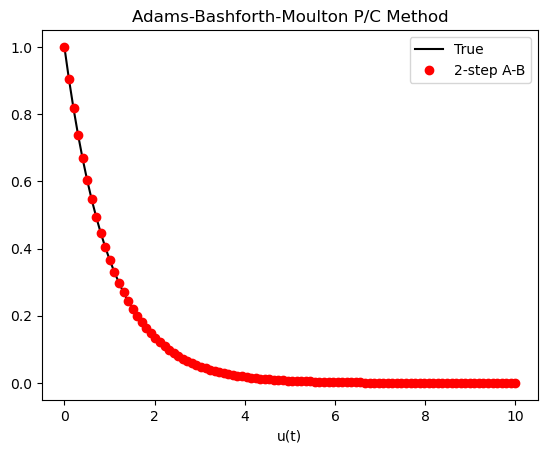

In [21]:
# One-step Adams-Bashforth-Moulton
# Mendefinisikan fungsi f(t,u)=−uf(t, u) = -uf(t,u)=−u
f = lambda t, u: -u # Bentuk turunan ODE yang akan diselesaikan
#Membuat solusi eksak untuk perbandingan
t_exact = numpy.linspace(0.0, 10.0, 100)    #nilai waktu dari 0 sampai 10 (100 titik)
u_exact = numpy.exp(-t_exact)
#Menyiapkan variabel untuk solusi numerik
N = 100 #bagi waktu menjadi 100 titik dari 0-10
t = numpy.linspace(0, 10.0, N)
delta_t = t[1] - t[0]   #delta_t: panjang setiap langkah waktu
U = numpy.empty(t.shape)
U[0] = 1.0
#Perulangan untuk menghitung solusi di setiap titik waktu
for n in range(t.shape[0] - 1):
    U[n+1] = U[n] + delta_t * f(t[n], U[n]) #Langkah prediksi
    U[n+1] = U[n] + 0.5 * delta_t * (f(t[n], U[n]) + f(t[n+1], U[n+1])) #langkah koreksi
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
#Menampilkan hasil grafik
axes.plot(t_exact, u_exact, 'k', label="True") #Warna hitam(k) untuk solusi e-t
axes.plot(t, U, 'ro', label="2-step A-B")   #warna merah(ro) untuk hasil metode numerik
axes.set_title("Adams-Bashforth-Moulton P/C Method")
axes.set_xlabel("t")
axes.set_xlabel("u(t)")
axes.legend(loc=1)
plt.show()

<>:54: SyntaxWarning: invalid escape sequence '\D'
<>:54: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Ideapad\AppData\Local\Temp\ipykernel_17116\440820577.py:54: SyntaxWarning: invalid escape sequence '\D'
  axes.set_xlabel("$\Delta t$")


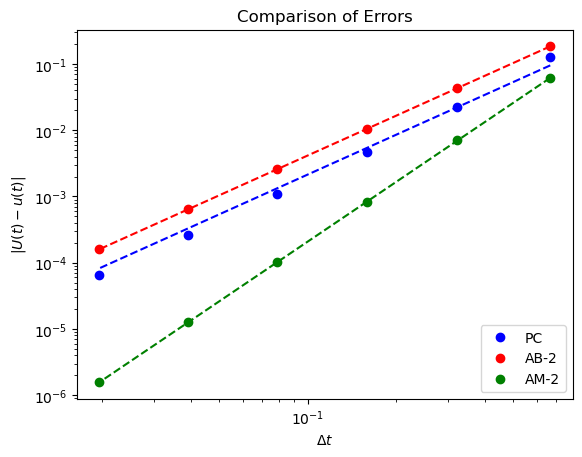

In [22]:
# Compare accuracy between RK-2, AB-2 and AM-2
f = lambda t, u: -u               #fungsi turunan: du/dt = -u
u_exact = lambda t: numpy.exp(-t) # Solusi eksak dari ODE
t_f = 10.0      # waktu akhir simulasi
num_steps = [2**n for n in range(4,10)] # banyaknya titik
delta_t = numpy.empty(len(num_steps))   # menyimpan langkah waktu (∆t)
error_ab = numpy.empty(len(num_steps))  # error metode Adams-Bashforth
error_am = numpy.empty(len(num_steps))  # error metode Adams-Moulton
error_pc = numpy.empty(len(num_steps))   # error metode Prediktor-Korektor
for (i, N) in enumerate(num_steps):
    t = numpy.linspace(0, t_f, N) # buat array waktu
    delta_t[i] = t[1] - t[0]    # hitung ∆t
    # RK-2 Sebagai Bootstrap (untuk 2 nilai awal)
    U_rk = numpy.empty(2)   
    U_rk[0] = 1.0    # kondisi awal
    U_rk[1] = U_rk[0] + 0.5 * delta_t[i] * f(t[0], U_rk[0])  # langkah prediksi
    U_rk[1] = U_rk[0] + delta_t[i] * f(t[0], U_rk[1])     # langkah koreksi  
    #Metode Adams-Bashforth 0rde 2
    U_ab = numpy.empty(t.shape)
    U_ab[:2] = U_rk[:2]
    for n in range(t.shape[0] - 2):
        U_ab[n+2] = U_ab[n + 1] + delta_t[i] / 2.0 * (-f(t[n], U_ab[n]) + 3.0 * f(t[n+1], U_ab[n+1]))
    #Metode Adams-Moulton orde 2
    U_am = numpy.empty(t.shape)
    U_am[:2] = U_ab[:2]
    decay_constant = 1.0
    integration_constant = 1.0 / (1.0 + 5.0 * decay_constant * delta_t[i] / 12.0)
    for n in range(t.shape[0] - 2):
        U_am[n+2] = (U_am[n+1] + decay_constant * delta_t[i] / 12.0 * (U_am[n] - 8.0 * U_am[n+1])) * integration_constant
    # Metode Prediktor-Korektor (PC: AB-1 + AM-1)
    U_pc = numpy.empty(t.shape)
    U_pc[0] = 1.0
    for n in range(t.shape[0] - 1):
        U_pc[n+1] = U_pc[n] + delta_t[i] * f(t[n], U_pc[n]) # Prediksi: AB-1
        U_pc[n+1] = U_pc[n] + 0.5 * delta_t[i] * (f(t[n], U_pc[n]) + f(t[n+1], U_pc[n+1]))  # Koreksi: AM-1   
    # Hitung Galat (Error) Tiap Metode
    error_ab[i] = numpy.linalg.norm(delta_t[i] * (U_ab - u_exact(t)), ord=1)
    error_am[i] = numpy.linalg.norm(delta_t[i] * (U_am - u_exact(t)), ord=1)
    error_pc[i] = numpy.linalg.norm(delta_t[i] * (U_pc - u_exact(t)), ord=1)
# Plot error vs. delta_t
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.loglog(delta_t, error_pc, 'bo', label='PC')    # error PC: biru
axes.loglog(delta_t, error_ab, 'ro', label='AB-2')  # error AB-2: merah
axes.loglog(delta_t, error_am, 'go', label="AM-2")  # error AM-2: hijau
#Tambahkan Garis Panduan Orde Teoritis
order_C = lambda delta_x, error, order: numpy.exp(numpy.log(error) - order * numpy.log(delta_x))
axes.loglog(delta_t, order_C(delta_t[1], error_pc[1], 2.0) * delta_t**2.0, '--b')   # Orde 2
axes.loglog(delta_t, order_C(delta_t[1], error_ab[1], 2.0) * delta_t**2.0, '--r')
axes.loglog(delta_t, order_C(delta_t[1], error_am[1], 3.0) * delta_t**3.0, '--g')   # AM-2: Orde 3
#Label dan Tampilkan
axes.legend(loc=4)
axes.set_title("Comparison of Errors")
axes.set_xlabel("$\Delta t$")
axes.set_ylabel("$|U(t) - u(t)|$")
plt.show()